In [1]:
import numpy as np
import pandas as pd
import ProGED as pg
import nltk
import random
import matplotlib.pyplot as plt

In [ ]:
class MCTSNode:
    def __init__(self, state, parent=None, applied_rule=None, depth=0):
        self.state = list(state)
        self.parent = parent
        self.applied_rule = applied_rule
        self.depth = depth
        self.children = []
        self.visits = 0
        self.value = 0.0

    def best_child(self, c_param=1.4):
        log_parent = np.log(self.visits if self.visits > 0 else 1)

        def uct(c):
            if c.visits == 0:
                return float('inf')
            exploitation = c.value / c.visits
            exploration = c_param * np.sqrt(log_parent / c.visits)
            return exploitation + exploration
        
        return max(self.children, key=uct)


class MCTS:
    def __init__(self, grammar, first_element, reward, max_rollout_depth=100):
        self.grammar = grammar
        self.first_element = first_element
        self.rules = self.grammar.grammar.productions()
        self.max_depth = max_rollout_depth
        self.reward = reward
        self.rollout_results = []

    def get_leftmost_nt(self, state):
        for index, symbol in enumerate(state):
            if isinstance(symbol, nltk.grammar.Nonterminal):
                return index, symbol
        return None, None

    def is_terminal(self, state):
        index, _ = self.get_leftmost_nt(state)
        return index is None

    def search(self, iterations):
        root = MCTSNode([nltk.grammar.Nonterminal(self.first_element)])
        for i in range(iterations):
            node = self.tree_policy(root)
            reward = self.simulate(node)
            self.backpropagate(node, reward)
    
        return self.rollout_results


    def tree_policy(self, node):
        while not self.is_terminal(node.state):
            index, nt = self.get_leftmost_nt(node.state)
            applicable = [r for r in self.rules if r.lhs() == nt]

            if len(node.children) < len(applicable):
                return self.expand(node,applicable,index)
            
            node = node.best_child()
        return node
    
    def expand(self, node, applicable, index):
        tried = [c.applied_rule for c in node.children]
        
        for prod in applicable:
            if prod not in tried:
                new_state = list(node.state)
                new_state[index:index+1] = list(prod.rhs())
                new_node = MCTSNode(new_state, node, prod, node.depth + 1)
                node.children.append(new_node)
                return new_node
        return node
    

    def simulate(self, node):

        current_state = list(node.state)
        depth = node.depth

        while not self.is_terminal(current_state) and depth < self.max_depth:
            # TODO: ali je tako ok?
            index, nt = self.get_leftmost_nt(current_state)
            rules = [r for r in self.rules if r.lhs() == nt]
            probs = [r.prob() for r in rules]
            selected = random.choices(rules, weights=probs, k=1)[0]
            current_state[index:index+1] = list(selected.rhs())
            depth += 1
        

        if not self.is_terminal(current_state):
            print("warning: reached max depth without terminal state")
            return 0.0

        state_string = "".join(str(t) for t in current_state)
        reward = self.reward(state_string)
        self.rollout_results.append((state_string, reward))
        return reward

    def backpropagate(self, node, reward):
        while node is not None:
            node.visits += 1
            node.value += reward
            node = node.parent


In [ ]:
def mc(grammar, iterations, utility):
    results = []
    for i in range(iterations):
        state = grammar.generate_one()[0]
        reward = utility(state)
        state_string = "".join(str(t) for t in state)
        results.append((state_string, reward))
    return results

In [3]:
# za zacetek vzamemo 3

p_a = 0.1
p_b = 0.9
p_c = 0.9

grammar = f"""
    S -> A B C [1.0]
    
    A -> A'a' [{p_a}]
    A -> 'a'   [{1 - p_a}]
    
    B -> B'b' [{p_b}]
    B -> 'b'   [{1 - p_b}]
    
    C -> C'c' [{p_c}]
    C -> 'c'   [{1 - p_c}]
"""
pg_grammar = pg.GeneratorGrammar(grammar)

def gini_impurity(expr):
    return 1 - sum(expr.count(c)**2 for c in set(expr))/len(expr)**2

mcts = MCTS(pg_grammar, first_element="S", reward=gini_impurity, max_rollout_depth=100)
results_mcts = mcts.search(500)
results_mc = mc(pg_grammar, 500, gini_impurity)
# results_mcts


TypeError: MCTS.__init__() got an unexpected keyword argument 'reward'

In [63]:
def plot_progress(results, name):

    scores = [item[1] for item in results]
    max_scores = np.maximum.accumulate(scores)
    plt.figure(figsize=(10, 5))
    
    plt.scatter(range(len(scores)), scores, color='black', alpha=0.5, s=10, label='nagradna funkcija iteracije')
    plt.plot(range(len(max_scores)), max_scores, color='blue', linewidth=2, label='nagradna funkcija najboljšega rezultata')
    
    plt.title(name)
    plt.xlabel('Število iteracij')
    plt.ylabel('Funkcija nagrade')
    plt.legend()
    
    plt.show()


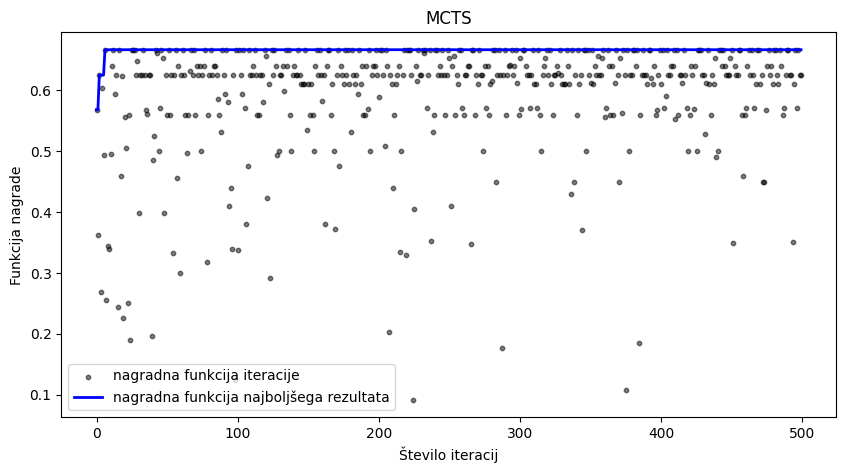

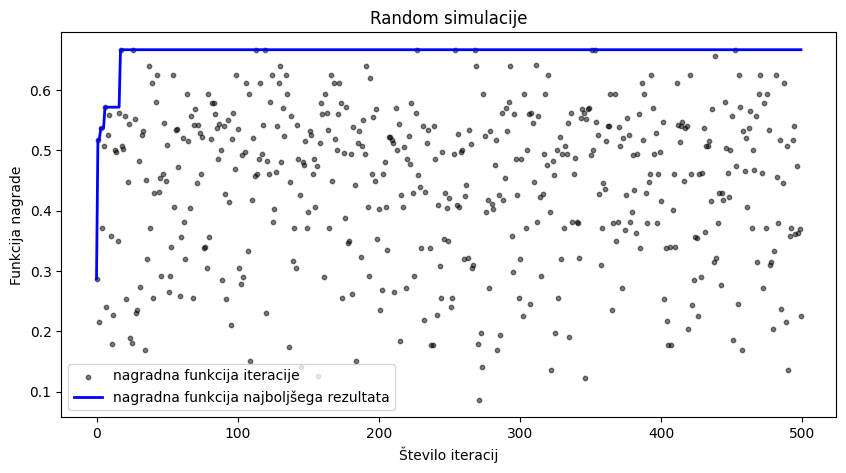

In [64]:
plot_progress(results_mcts, name="MCTS")
plot_progress(results_mc, name="Random simulacije")